# Burgers 1D: Flow Matching vs Rectified Flow

This notebook compares two flow-based generative models for solving the 1D Burgers equation:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

**Methods compared:**
- **Flow Matching**: Uniform time sampling
- **Rectified Flow**: Logit-normal time sampling (concentrates samples near t=0 and t=1)

**Contents:**
1. Load models data
2. Generate predictions
3. Visual comparison
4. Error metrics
5. Flow trajectory comparison
6. Sampling efficiency (number of steps)
7. Path straightness analysis

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from flowpde.datasets.exponax import BurgersGenerator
from flowpde.models.resnet import ResNet
from flowpde.flows.flow_matching import FlowMatching

plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Load Models and Data

In [3]:
# Configuration
SPATIAL_SIZE = 160
BASE_CHANNELS = 64

FM_CHECKPOINT = project_root / "results" / "burgers_1d_flowmatchingg" / "checkpoints" / "best_model.pt"
RF_CHECKPOINT = project_root / "results" / "burgers_1d_rectified" / "checkpoints" / "best_model.pt"

print(f"Flow Matching checkpoint exists: {FM_CHECKPOINT.exists()}")
print(f"Rectified Flow checkpoint exists: {RF_CHECKPOINT.exists()}")

Flow Matching checkpoint exists: True
Rectified Flow checkpoint exists: True


In [5]:
def create_model():
    return ResNet(
        spatial_dim=1,
        spatial_size=SPATIAL_SIZE,
        base_channels=BASE_CHANNELS,
        blocks_per_stage=[2, 2, 2],
        solution_channels=1,
        condition_channels=1,
        downsample=False,
        return_spatial=False,
    )

# Load Flow Matching model
model_fm = create_model()
ckpt_fm = torch.load(FM_CHECKPOINT, map_location=device)
model_fm.load_state_dict(ckpt_fm['model_state'])
model_fm = model_fm.to(device).eval()

# Load Rectified Flow model
model_rf = create_model()
ckpt_rf = torch.load(RF_CHECKPOINT, map_location=device)
model_rf.load_state_dict(ckpt_rf['model_state'])
model_rf = model_rf.to(device).eval()

print(f"Models loaded. Parameters: {sum(p.numel() for p in model_fm.parameters()):,}")

Models loaded. Parameters: 774,593


In [6]:
# Create flow wrappers
flow_fm = FlowMatching(model=model_fm, path='linear', time_sampler='uniform')
flow_rf = FlowMatching(model=model_rf, path='linear', time_sampler='logit_normal')

flows = {
    'Flow Matching': flow_fm,
    'Rectified Flow': flow_rf,
}
print("Flow wrappers created")

Flow wrappers created


In [8]:
generator = BurgersGenerator(
        num_spatial_dims=1,
        num_points=160,
        domain_extent=1.0,
        dt=0.001,
        num_steps=50,
        diffusivity_min=1e-4,
        diffusivity_max=1e-2,
        torch_device=device,
    )
test_dataset = generator.generate(num_samples=100, seed=0, problem='forward')
print(f"Test samples: {len(test_dataset)}")

Generated Burgers 1D dataset: 100 samples, 160 grid, 50 steps (dt=0.001), ν ~ LogUniform(1e-04, 1e-02)
Test samples: 100


In [9]:
# Select test samples
N_SAMPLES = 32
np.random.seed(42)
indices = np.random.choice(len(test_dataset), N_SAMPLES, replace=False)

initial_states = torch.stack([test_dataset[i]['input'] for i in indices])
final_states_gt = torch.stack([test_dataset[i]['target'] for i in indices])

print(f"Initial state shape: {initial_states.shape}")
print(f"Final state shape: {final_states_gt.shape}")

Initial state shape: torch.Size([32, 1, 160])
Final state shape: torch.Size([32, 1, 160])


## 2. Generate Predictions

In [10]:
def generate_samples(flow, conditions, n_steps=50, solver='dopri5'):
    flow.model.eval()
    with torch.no_grad():
        samples = flow.sample(
            condition=conditions,
            n_steps=n_steps,
            solver=solver,
        )
    return samples

conditions = initial_states.to(device)

# Generate predictions for both methods
predictions = {}
for name, flow in flows.items():
    pred = generate_samples(flow, conditions, n_steps=50, solver='dopri5')
    predictions[name] = pred.cpu().view(N_SAMPLES, 1, SPATIAL_SIZE)
    print(f"{name}: done")

Flow Matching: done
Rectified Flow: done


## 3. Visual Comparison

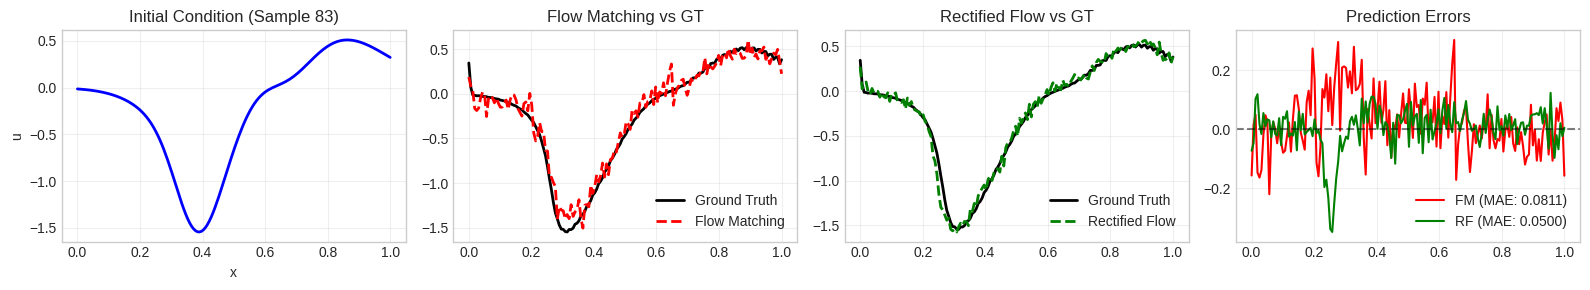

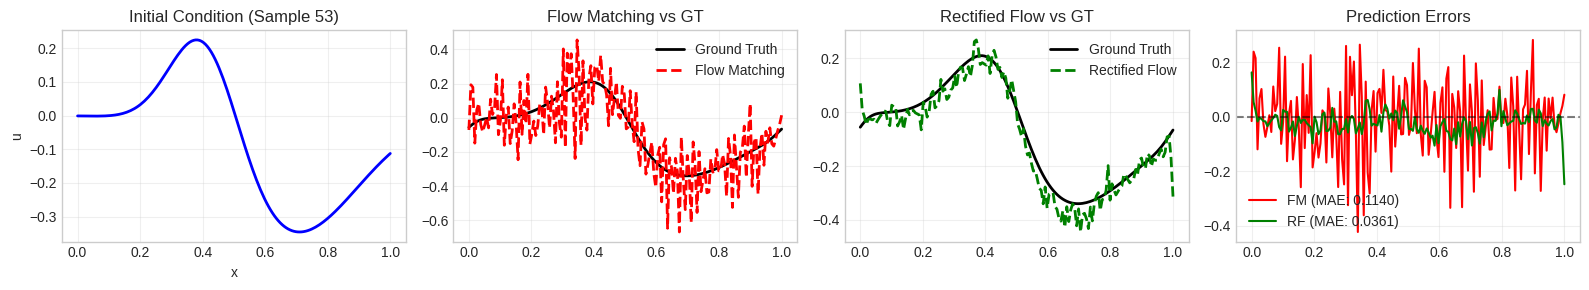

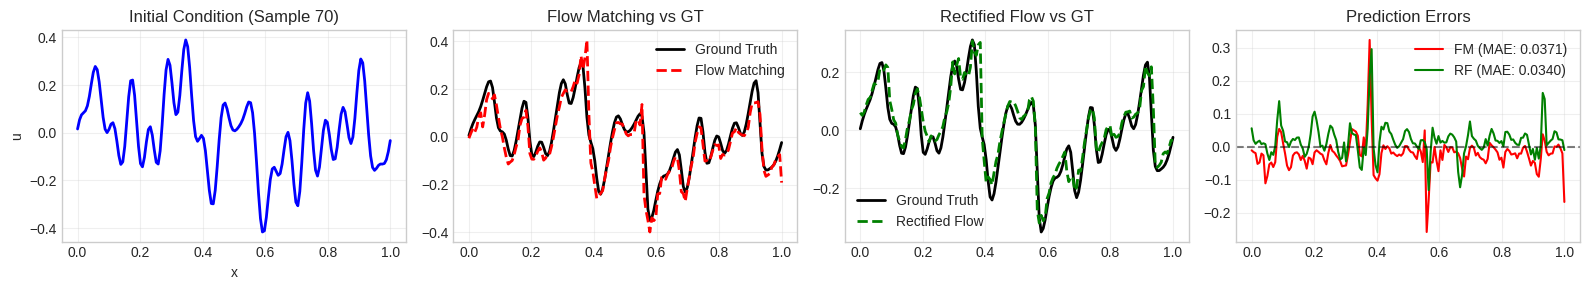

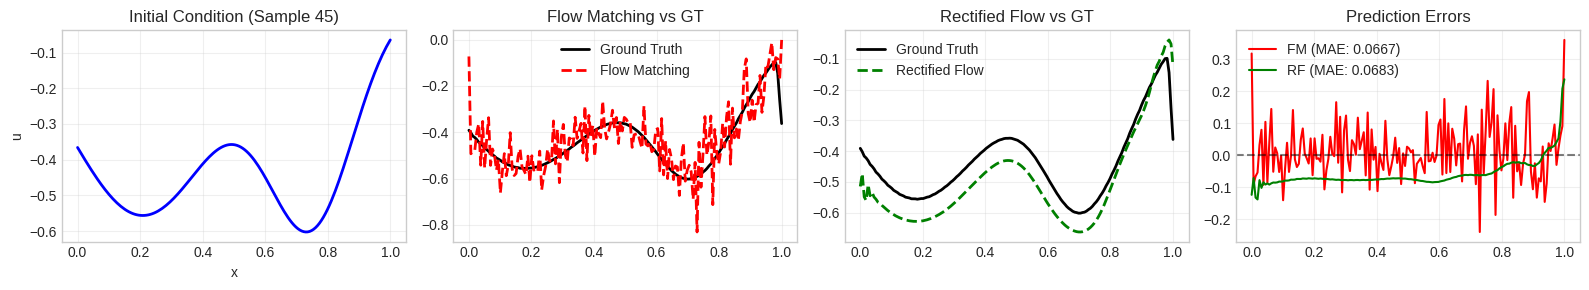

In [13]:
def plot_1d_comparison(initial, gt, pred_fm, pred_rf, idx):
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    x = np.linspace(0, 1, SPATIAL_SIZE)
    
    # Initial condition
    axes[0].plot(x, initial.cpu().squeeze().numpy(), 'b-', linewidth=2)
    axes[0].set_title(f'Initial Condition (Sample {idx})')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('u')
    axes[0].grid(True, alpha=0.3)
    
    # Ground truth vs predictions
    axes[1].plot(x, gt.cpu().squeeze().numpy(), 'k-', linewidth=2, label='Ground Truth')
    axes[1].plot(x, pred_fm.cpu().squeeze().numpy(), 'r--', linewidth=2, label='Flow Matching')
    axes[1].set_title('Flow Matching vs GT')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(x, gt.cpu().squeeze().numpy(), 'k-', linewidth=2, label='Ground Truth')
    axes[2].plot(x, pred_rf.cpu().squeeze().numpy(), 'g--', linewidth=2, label='Rectified Flow')
    axes[2].set_title('Rectified Flow vs GT')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Errors
    error_fm = (pred_fm.cpu().squeeze().numpy() - gt.cpu().squeeze().numpy())
    error_rf = (pred_rf.cpu().squeeze().numpy() - gt.cpu().squeeze().numpy())
    axes[3].plot(x, error_fm, 'r-', linewidth=1.5, label=f'FM (MAE: {np.abs(error_fm).mean():.4f})')
    axes[3].plot(x, error_rf, 'g-', linewidth=1.5, label=f'RF (MAE: {np.abs(error_rf).mean():.4f})')
    axes[3].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[3].set_title('Prediction Errors')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot first 4 samples
for i in range(4):
    fig = plot_1d_comparison(
        initial_states[i], final_states_gt[i],
        predictions['Flow Matching'][i], predictions['Rectified Flow'][i],
        indices[i]
    )
    plt.show()

## 4. Error Metrics

In [15]:
def compute_metrics(pred, gt):
    pred_flat = pred.flatten(start_dim=1)
    gt_flat = gt.flatten(start_dim=1)
    
    mse = ((pred_flat - gt_flat) ** 2).mean(dim=1)
    mae = (pred_flat - gt_flat).abs().mean(dim=1)
    rel_l2 = torch.sqrt(mse) / (torch.sqrt((gt_flat ** 2).mean(dim=1)) + 1e-8)
    
    return {'mse': mse, 'mae': mae, 'rel_l2': rel_l2}

metrics = {}
for name, pred in predictions.items():
    metrics[name] = compute_metrics(pred.cpu().squeeze(), final_states_gt.cpu().squeeze())

# Display metrics
print("=" * 60)
print(f"{'Method':<20} {'MSE':>12} {'MAE':>12} {'Rel L2':>12}")
print("=" * 60)
for name, m in metrics.items():
    print(f"{name:<20} {m['mse'].mean():.6f}    {m['mae'].mean():.6f}    {m['rel_l2'].mean():.6f}")
print("=" * 60)

Method                        MSE          MAE       Rel L2
Flow Matching        0.126573    0.148642    0.537365
Rectified Flow       0.155749    0.152009    0.519072


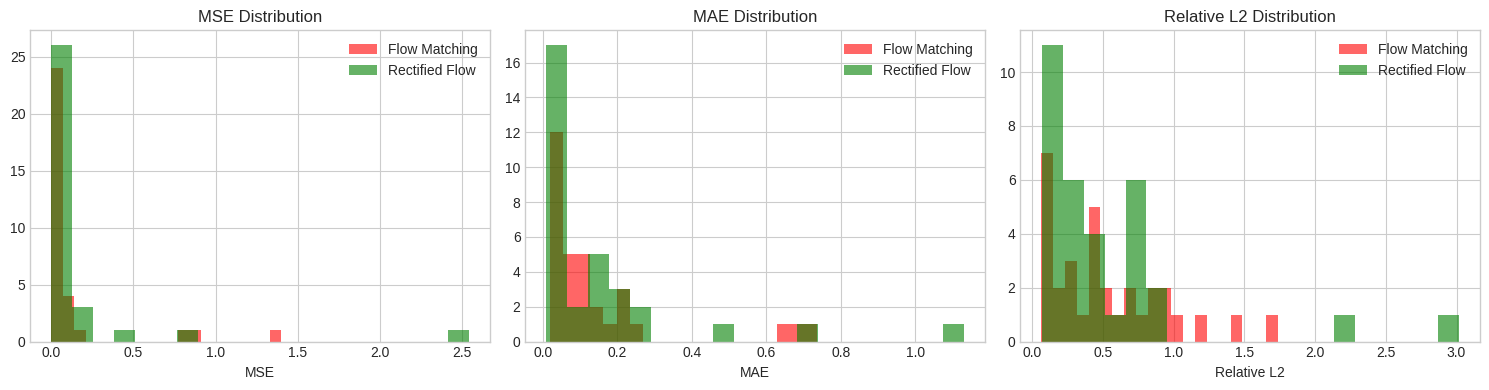

In [16]:
# Error distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'Flow Matching': 'red', 'Rectified Flow': 'green'}

for name, m in metrics.items():
    axes[0].hist(m['mse'].numpy(), bins=20, alpha=0.6, label=name, color=colors[name])
axes[0].set_xlabel('MSE')
axes[0].set_title('MSE Distribution')
axes[0].legend()

for name, m in metrics.items():
    axes[1].hist(m['mae'].numpy(), bins=20, alpha=0.6, label=name, color=colors[name])
axes[1].set_xlabel('MAE')
axes[1].set_title('MAE Distribution')
axes[1].legend()

for name, m in metrics.items():
    axes[2].hist(m['rel_l2'].numpy(), bins=20, alpha=0.6, label=name, color=colors[name])
axes[2].set_xlabel('Relative L2')
axes[2].set_title('Relative L2 Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

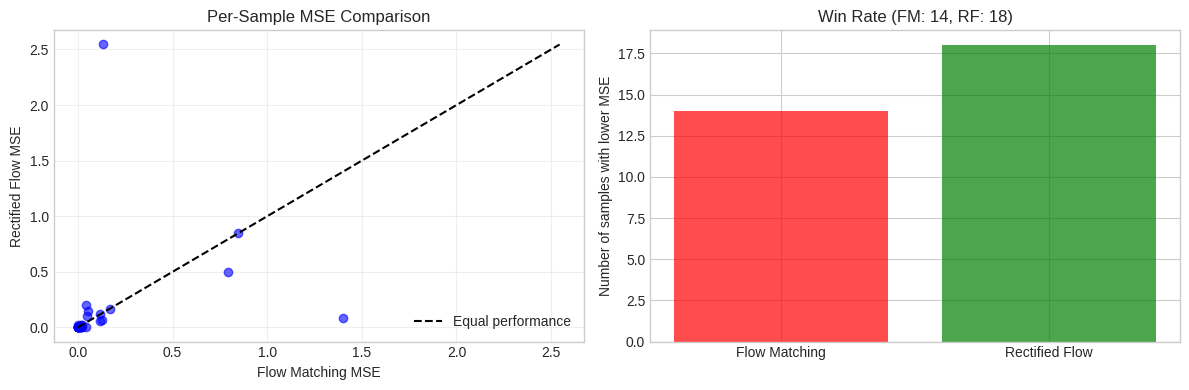

In [17]:
# Per-sample comparison
mse_fm = metrics['Flow Matching']['mse'].numpy()
mse_rf = metrics['Rectified Flow']['mse'].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter plot
axes[0].scatter(mse_fm, mse_rf, alpha=0.6, c='blue')
max_val = max(mse_fm.max(), mse_rf.max())
axes[0].plot([0, max_val], [0, max_val], 'k--', label='Equal performance')
axes[0].set_xlabel('Flow Matching MSE')
axes[0].set_ylabel('Rectified Flow MSE')
axes[0].set_title('Per-Sample MSE Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Win rate
fm_wins = (mse_fm < mse_rf).sum()
rf_wins = (mse_rf < mse_fm).sum()
ties = (mse_fm == mse_rf).sum()

axes[1].bar(['Flow Matching', 'Rectified Flow'], [fm_wins, rf_wins], color=['red', 'green'], alpha=0.7)
axes[1].set_ylabel('Number of samples with lower MSE')
axes[1].set_title(f'Win Rate (FM: {fm_wins}, RF: {rf_wins})')

plt.tight_layout()
plt.show()

## 5. Flow Trajectory Comparison

In [18]:
def generate_trajectory(flow, condition, n_steps=20):
    from flowpde.solvers.ode_solvers import VelocityField
    from torchdiffeq import odeint
    
    flow.model.eval()
    dev = next(flow.model.parameters()).device
    
    condition_flat = condition.flatten(start_dim=1).to(dev)
    batch_size, dim = condition_flat.shape
    
    x_init = torch.randn(batch_size, dim, device=dev)
    t_eval = torch.linspace(0, 1, n_steps + 1, device=dev)
    
    velocity_field = VelocityField(flow.model, condition_flat)
    
    with torch.no_grad():
        trajectory = odeint(velocity_field, x_init, t_eval, method='rk4')
    
    return trajectory.cpu(), t_eval.cpu()

# Generate trajectories for both methods
sample_idx = 0
condition = initial_states[sample_idx:sample_idx+1].to(device)

torch.manual_seed(0)  # Same noise for fair comparison
traj_fm, t_fm = generate_trajectory(flow_fm, condition, n_steps=20)

torch.manual_seed(0)
traj_rf, t_rf = generate_trajectory(flow_rf, condition, n_steps=20)

print(f"Trajectories generated. Shape: {traj_fm.shape}")

Trajectories generated. Shape: torch.Size([21, 1, 160])


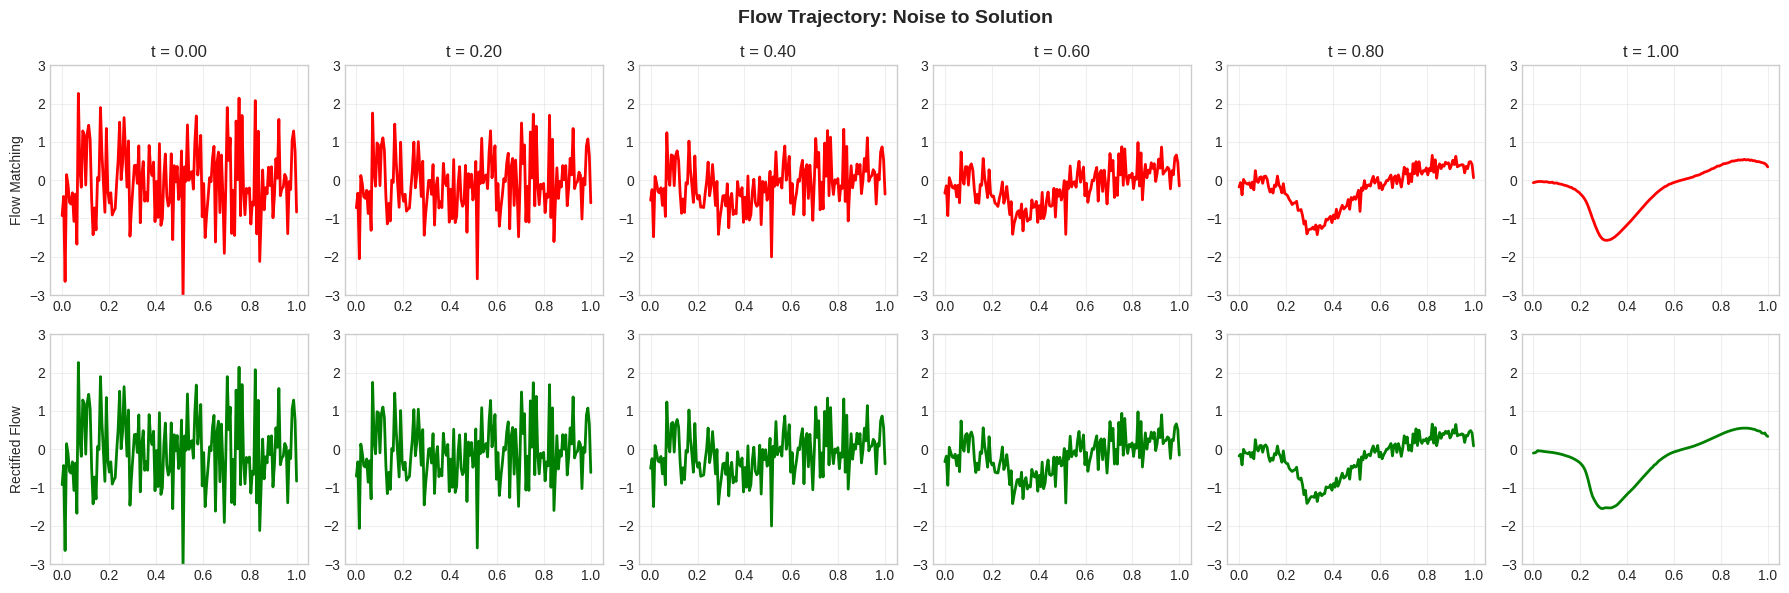

In [19]:
# Visualize trajectories side by side
n_frames = 6
frame_indices = np.linspace(0, len(traj_fm) - 1, n_frames, dtype=int)
x = np.linspace(0, 1, SPATIAL_SIZE)

fig, axes = plt.subplots(2, n_frames, figsize=(18, 6))

for i, idx in enumerate(frame_indices):
    t = t_fm[idx].item()
    
    # Flow Matching
    state_fm = traj_fm[idx, 0].view(SPATIAL_SIZE).numpy()
    axes[0, i].plot(x, state_fm, 'r-', linewidth=2)
    axes[0, i].set_title(f't = {t:.2f}')
    axes[0, i].set_ylim(-3, 3)
    axes[0, i].grid(True, alpha=0.3)
    if i == 0:
        axes[0, i].set_ylabel('Flow Matching')
    
    # Rectified Flow
    state_rf = traj_rf[idx, 0].view(SPATIAL_SIZE).numpy()
    axes[1, i].plot(x, state_rf, 'g-', linewidth=2)
    axes[1, i].set_ylim(-3, 3)
    axes[1, i].grid(True, alpha=0.3)
    if i == 0:
        axes[1, i].set_ylabel('Rectified Flow')

plt.suptitle('Flow Trajectory: Noise to Solution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Sampling Efficiency (Number of Steps)

Testing sampling efficiency...
n_steps=5: done
n_steps=10: done
n_steps=20: done


/home/breziskato/Desktop/projects/.venv/flowpde/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Euler: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


n_steps=50: done
n_steps=100: done
n_steps=200: done


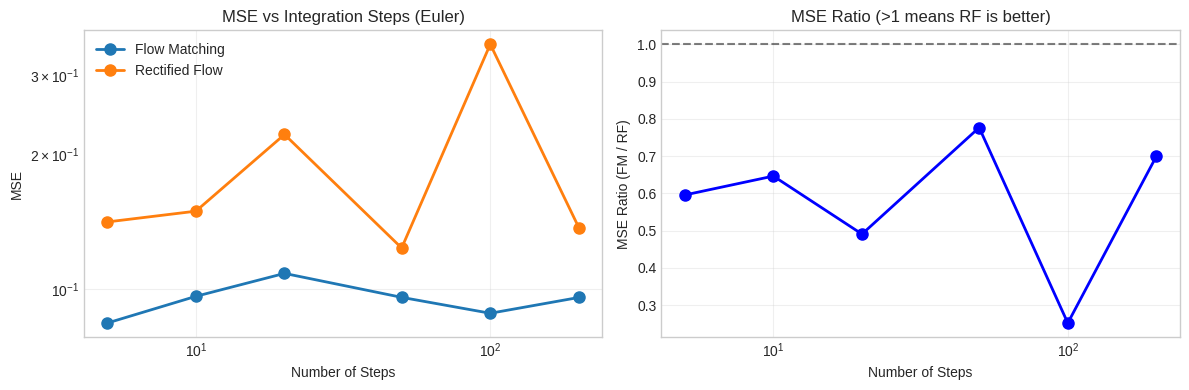

In [21]:
# Test how error changes with number of integration steps
step_counts = [5, 10, 20, 50, 100, 200]
convergence = {'Flow Matching': [], 'Rectified Flow': []}

print("Testing sampling efficiency...")
for n_steps in step_counts:
    for name, flow in flows.items():
        pred = generate_samples(flow, conditions, n_steps=n_steps, solver='euler')
        pred = pred.cpu().view(N_SAMPLES, 1, SPATIAL_SIZE)
        m = compute_metrics(pred.cpu(), final_states_gt.cpu())
        convergence[name].append(m['mse'].mean().item())
    print(f"n_steps={n_steps}: done")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, mse_vals in convergence.items():
    axes[0].loglog(step_counts, mse_vals, 'o-', linewidth=2, markersize=8, label=name)
axes[0].set_xlabel('Number of Steps')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE vs Integration Steps (Euler)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Speedup: steps needed to reach same MSE
fm_mse = np.array(convergence['Flow Matching'])
rf_mse = np.array(convergence['Rectified Flow'])
ratio = fm_mse / rf_mse

axes[1].semilogx(step_counts, ratio, 'b-o', linewidth=2, markersize=8)
axes[1].axhline(1, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Steps')
axes[1].set_ylabel('MSE Ratio (FM / RF)')
axes[1].set_title('MSE Ratio (>1 means RF is better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Path Straightness Analysis

Rectified Flow aims to learn straighter transport paths. Straighter paths mean the velocity is more constant along the path.

In [22]:
def compute_path_straightness(trajectory):
    """
    Compute path straightness metrics.
    
    A perfectly straight path has constant velocity.
    We measure the variance of step sizes along the path.
    """
    # Compute step differences
    steps = trajectory[1:] - trajectory[:-1]  # (n_steps, batch, dim)
    step_norms = torch.norm(steps, dim=2)  # (n_steps, batch)
    
    # Variance of step norms (lower = straighter)
    step_variance = step_norms.var(dim=0).mean().item()
    
    # Total path length
    path_length = step_norms.sum(dim=0).mean().item()
    
    # Straight-line distance
    straight_dist = torch.norm(trajectory[-1] - trajectory[0], dim=1).mean().item()
    
    # Straightness ratio (1 = perfectly straight)
    straightness = straight_dist / (path_length + 1e-8)
    
    return {
        'step_variance': step_variance,
        'path_length': path_length,
        'straight_dist': straight_dist,
        'straightness': straightness,
    }

# Compute for multiple samples
n_test = 10
straightness_results = {'Flow Matching': [], 'Rectified Flow': []}

for i in range(n_test):
    cond = initial_states[i:i+1].to(device)
    
    torch.manual_seed(i)
    traj_fm, _ = generate_trajectory(flow_fm, cond, n_steps=50)
    straightness_results['Flow Matching'].append(compute_path_straightness(traj_fm))
    
    torch.manual_seed(i)
    traj_rf, _ = generate_trajectory(flow_rf, cond, n_steps=50)
    straightness_results['Rectified Flow'].append(compute_path_straightness(traj_rf))

# Aggregate results
print("Path Straightness Analysis")
print("=" * 50)
for name in ['Flow Matching', 'Rectified Flow']:
    results = straightness_results[name]
    avg_straightness = np.mean([r['straightness'] for r in results])
    avg_variance = np.mean([r['step_variance'] for r in results])
    print(f"{name}:")
    print(f"  Straightness ratio: {avg_straightness:.4f}")
    print(f"  Step variance: {avg_variance:.6f}")

Path Straightness Analysis
Flow Matching:
  Straightness ratio: 0.9862
  Step variance: 0.000749
Rectified Flow:
  Straightness ratio: 0.9829
  Step variance: 0.000572


/tmp/ipykernel_108062/2091597483.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([fm_straightness, rf_straightness], labels=['Flow Matching', 'Rectified Flow'])
/tmp/ipykernel_108062/2091597483.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([fm_var, rf_var], labels=['Flow Matching', 'Rectified Flow'])


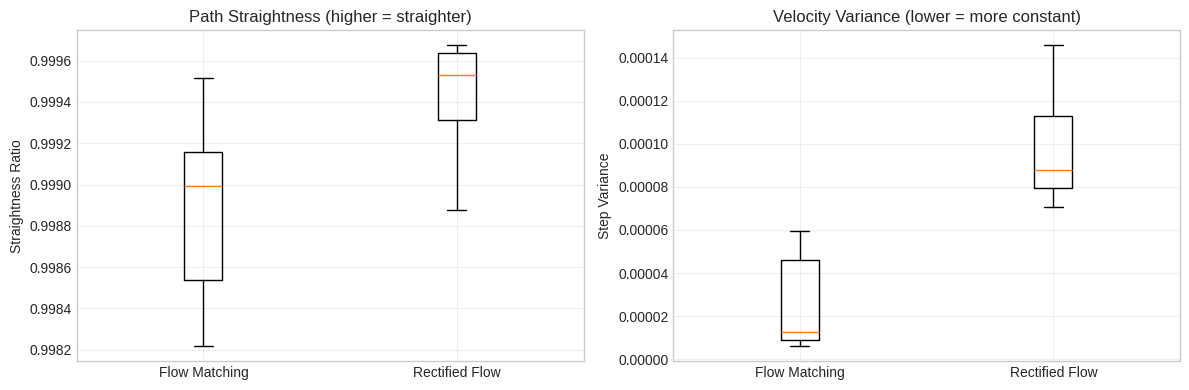

In [16]:
# Visualize path straightness
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fm_straightness = [r['straightness'] for r in straightness_results['Flow Matching']]
rf_straightness = [r['straightness'] for r in straightness_results['Rectified Flow']]

axes[0].boxplot([fm_straightness, rf_straightness], labels=['Flow Matching', 'Rectified Flow'])
axes[0].set_ylabel('Straightness Ratio')
axes[0].set_title('Path Straightness (higher = straighter)')
axes[0].grid(True, alpha=0.3)

fm_var = [r['step_variance'] for r in straightness_results['Flow Matching']]
rf_var = [r['step_variance'] for r in straightness_results['Rectified Flow']]

axes[1].boxplot([fm_var, rf_var], labels=['Flow Matching', 'Rectified Flow'])
axes[1].set_ylabel('Step Variance')
axes[1].set_title('Velocity Variance (lower = more constant)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary

In [23]:
print("=" * 60)
print("       BURGERS 1D: FLOW MATCHING vs RECTIFIED FLOW")
print("=" * 60)

print("\nDataset:")
print(f"  Grid size: {SPATIAL_SIZE}")
print(f"  Test samples: {N_SAMPLES}")

print("\nModel:")
print(f"  Architecture: ResNet (1D)")
print(f"  Parameters: {sum(p.numel() for p in model_fm.parameters()):,}")

print("\nPerformance (50 steps, dopri5):")
print(f"  {'Method':<20} {'MSE':>12} {'MAE':>12} {'Rel L2':>12}")
print(f"  {'-'*56}")
for name, m in metrics.items():
    print(f"  {name:<20} {m['mse'].mean():.6f}    {m['mae'].mean():.6f}    {m['rel_l2'].mean():.6f}")

print("\nPath Straightness:")
for name in ['Flow Matching', 'Rectified Flow']:
    results = straightness_results[name]
    avg_s = np.mean([r['straightness'] for r in results])
    print(f"  {name}: {avg_s:.4f}")

print("\n" + "=" * 60)
print("Analysis Complete")
print("=" * 60)

       BURGERS 1D: FLOW MATCHING vs RECTIFIED FLOW

Dataset:
  Grid size: 160
  Test samples: 32

Model:
  Architecture: ResNet (1D)
  Parameters: 774,593

Performance (50 steps, dopri5):
  Method                        MSE          MAE       Rel L2
  --------------------------------------------------------
  Flow Matching        0.126573    0.148642    0.537365
  Rectified Flow       0.155749    0.152009    0.519072

Path Straightness:
  Flow Matching: 0.9862
  Rectified Flow: 0.9829

Analysis Complete
